# Prévision du risque d'inondation avec LSTM

Ce notebook explore l'utilisation d'un modèle LSTM pour prédire le risque d'inondation à partir des observations météorologiques horaires disponibles dans `flood_api/donnees`. L'objectif est de transformer la série temporelle en séquences et d'entraîner un réseau récurrent supervisé.


## Plan de l'expérience

1. Charger les données météo et reproduire les métadonnées (coordonnées, altitude, etc.).
2. Filtrer la saison des pluies et préparer les variables utiles (pluie, humidité des sols, VPD, etc.).
3. Construire la cible `flood_risk_label_v2` basée sur les quantiles de pluie future et d'humidité.
4. Normaliser les séries puis générer des séquences glissantes pour alimenter le LSTM.
5. Entraîner un modèle LSTM (PyTorch) sur 80 % des données et évaluer sur les 20 % restants (accuracy, précision, rappel, F1, ROC-AUC).
6. Sauvegarder le modèle et fournir des pistes d'amélioration.


In [ ]:
# Optionnel: installer les dépendances manquantes
# !pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
# !pip install -q pandas numpy matplotlib seaborn scikit-learn joblib

In [1]:
from __future__ import annotations

import json
import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, Dataset
except ImportError as exc:
    raise ImportError("PyTorch est nécessaire pour ce notebook. Installez-le avant d'exécuter la suite.") from exc

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
sns.set_palette("deep")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé: {DEVICE}")


Appareil utilisé: cpu


## Chargement des données météo

Nous reprenons la logique de `model.ipynb` pour lire les fichiers CSV (les trois premières lignes contiennent des métadonnées).


In [2]:
DATA_DIR = Path("donnees")
RAINY_MONTHS = {6, 7, 8, 9, 10}
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Répertoire de travail: {Path.cwd()}")
print(f"Fichiers disponibles: {[p.name for p in DATA_DIR.glob('*.csv')]}")


Répertoire de travail: /Users/mac/Documents/Innond/flood_api
Fichiers disponibles: ['keur_massar_weather.csv', 'Touba_weather.csv', 'kaolack_leona_weather.csv', 'Saintlouis_weather.csv']


In [3]:
def clean_column_name(raw: str) -> str:
    name = (raw.strip().lower()
                .replace(" ", "_")
                .replace("/", "_")
                .replace("-", "_")
                .replace("(", "")
                .replace(")", "")
                .replace("%", "pct")
                .replace("°", "")
                .replace("²", "2")
                .replace("³", "3")
                .replace(".", "_"))
    while "__" in name:
        name = name.replace("__", "_")
    return name


def forward_sum(series: pd.Series, horizon: int) -> pd.Series:
    values = series.to_numpy(dtype=float)
    result = np.full_like(values, np.nan, dtype=float)
    cumsum = np.cumsum(np.insert(values, 0, 0.0))
    for idx in range(len(values)):
        start = idx + 1
        end = min(len(values), idx + horizon + 1)
        if start >= len(cumsum):
            result[idx] = np.nan
            continue
        result[idx] = cumsum[end] - cumsum[start]
    return pd.Series(result, index=series.index)


def load_weather_file(path: Path) -> Tuple[pd.DataFrame, Dict[str, object]]:
    meta_df = pd.read_csv(path, nrows=1)
    meta = meta_df.iloc[0].to_dict()
    data = pd.read_csv(path, skiprows=3)
    data.columns = [clean_column_name(col) for col in data.columns]
    data["time"] = pd.to_datetime(data["time"], utc=False)
    location_key = path.stem.replace("_weather", "").lower()
    data["location_key"] = location_key
    data["location_name"] = location_key.replace("_", " ").title()
    for field in ("latitude", "longitude", "elevation", "timezone"):
        if field in meta:
            data[field] = meta[field]
    meta["location_key"] = location_key
    meta["location_name"] = location_key.replace("_", " ").title()
    return data, meta


def load_all_weather(data_dir: Path) -> Tuple[pd.DataFrame, pd.DataFrame]:
    frames: List[pd.DataFrame] = []
    metadata: List[Dict[str, object]] = []
    for csv_path in sorted(data_dir.glob("*_weather.csv")):
        frame, meta = load_weather_file(csv_path)
        frames.append(frame)
        metadata.append(meta)
    weather = pd.concat(frames, ignore_index=True).sort_values(["location_key", "time"])
    meta_df = pd.DataFrame(metadata)
    return weather, meta_df


In [4]:
weather_raw, site_metadata = load_all_weather(DATA_DIR)
print("Dimensions brutes :", weather_raw.shape)
site_metadata

Dimensions brutes : (316992, 49)


,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation,location_key,location_name
0,15.992970,-16.433289,0.0,0,GMT,GMT,saintlouis,Saintlouis
1,14.868190,-15.852753,45.0,0,GMT,GMT,touba,Touba
2,14.165202,-16.038788,5.0,0,GMT,GMT,kaolack_leona,Kaolack Leona
3,14.797891,-17.262573,3.0,0,GMT,GMT,keur_massar,Keur Massar


In [5]:
weather_raw.head()

,time,temperature_2m_c,relative_humidity_2m_pct,dew_point_2m_c,apparent_temperature_c,precipitation_mm,rain_mm,snowfall_cm,snow_depth_m,weather_code_wmo_code,...,diffuse_radiation_instant_w_m2,direct_normal_irradiance_instant_w_m2,global_tilted_irradiance_instant_w_m2,terrestrial_radiation_instant_w_m2,location_key,location_name,latitude,longitude,elevation,timezone
158496,2016-06-07 00:00:00,24.4,73,19.3,26.2,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,kaolack_leona,Kaolack Leona,14.165202,-16.038788,5.0,GMT
158497,2016-06-07 01:00:00,23.5,77,19.2,25.1,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,kaolack_leona,Kaolack Leona,14.165202,-16.038788,5.0,GMT
158498,2016-06-07 02:00:00,22.7,80,19.1,24.3,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,kaolack_leona,Kaolack Leona,14.165202,-16.038788,5.0,GMT
158499,2016-06-07 03:00:00,22.0,84,19.2,23.7,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,kaolack_leona,Kaolack Leona,14.165202,-16.038788,5.0,GMT
158500,2016-06-07 04:00:00,21.5,88,19.4,23.5,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,kaolack_leona,Kaolack Leona,14.165202,-16.038788,5.0,GMT


## Filtrer la saison des pluies et dériver des indicateurs

Nous conservons les observations de juin à octobre et créons des agrégats glissants similaires à `model.ipynb` (pluie, humidité des sols, VPD, etc.).


In [6]:
weather_rainy = weather_raw[weather_raw["time"].dt.month.isin(RAINY_MONTHS)].copy()
weather_rainy["month"] = weather_rainy["time"].dt.month
weather_rainy.sort_values(["location_key", "time"], inplace=True)
weather_rainy.reset_index(drop=True, inplace=True)
print(f"Observations saison des pluies: {len(weather_rainy):,}")
weather_rainy.head()


Observations saison des pluies: 133,632


,time,temperature_2m_c,relative_humidity_2m_pct,dew_point_2m_c,apparent_temperature_c,precipitation_mm,rain_mm,snowfall_cm,snow_depth_m,weather_code_wmo_code,...,direct_normal_irradiance_instant_w_m2,global_tilted_irradiance_instant_w_m2,terrestrial_radiation_instant_w_m2,location_key,location_name,latitude,longitude,elevation,timezone,month
0,2016-06-07 00:00:00,24.4,73,19.3,26.2,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,kaolack_leona,Kaolack Leona,14.165202,-16.038788,5.0,GMT,6
1,2016-06-07 01:00:00,23.5,77,19.2,25.1,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,kaolack_leona,Kaolack Leona,14.165202,-16.038788,5.0,GMT,6
2,2016-06-07 02:00:00,22.7,80,19.1,24.3,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,kaolack_leona,Kaolack Leona,14.165202,-16.038788,5.0,GMT,6
3,2016-06-07 03:00:00,22.0,84,19.2,23.7,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,kaolack_leona,Kaolack Leona,14.165202,-16.038788,5.0,GMT,6
4,2016-06-07 04:00:00,21.5,88,19.4,23.5,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,kaolack_leona,Kaolack Leona,14.165202,-16.038788,5.0,GMT,6


In [7]:
TOP_SOIL_COL = "soil_moisture_0_to_7cm_m3_m3"
SUB_SOIL_COL = "soil_moisture_7_to_28cm_m3_m3"
PRECIP_COL = "precipitation_mm"
VPD_COL = "vapour_pressure_deficit_kpa"
HUMIDITY_COL = "relative_humidity_2m_pct"
TEMP_COL = "temperature_2m_c"
PRESSURE_COL = "pressure_msl_hpa"
WIND_GUST_COL = "wind_gusts_10m_km_h"

rolling_windows = (6, 12, 24, 48, 72)
engineered = weather_rainy.copy()

for window in rolling_windows:
    grouped = engineered.groupby("location_key")
    engineered[f"rain_sum_{window}h"] = grouped[PRECIP_COL].transform(lambda s: s.rolling(window, min_periods=1).sum())
    engineered[f"rain_max_{window}h"] = grouped[PRECIP_COL].transform(lambda s: s.rolling(window, min_periods=1).max())
    engineered[f"soil_top_mean_{window}h"] = grouped[TOP_SOIL_COL].transform(lambda s: s.rolling(window, min_periods=1).mean())
    engineered[f"soil_sub_mean_{window}h"] = grouped[SUB_SOIL_COL].transform(lambda s: s.rolling(window, min_periods=1).mean())
    engineered[f"humidity_mean_{window}h"] = grouped[HUMIDITY_COL].transform(lambda s: s.rolling(window, min_periods=1).mean())
    engineered[f"vpd_mean_{window}h"] = grouped[VPD_COL].transform(lambda s: s.rolling(window, min_periods=1).mean())

for horizon in (6, 12, 24):
    engineered[f"future_rain_{horizon}h"] = engineered.groupby("location_key")[PRECIP_COL].transform(lambda s: forward_sum(s, horizon))

engineered["rain_intensity_ratio"] = engineered["rain_sum_24h"] / (engineered["rain_sum_72h"] + 1e-3)
engineered["soil_moisture_gradient"] = engineered["soil_top_mean_24h"] - engineered["soil_sub_mean_24h"]
engineered["soil_moisture_index"] = engineered["soil_top_mean_24h"] + engineered["soil_sub_mean_24h"]

engineered.head()


,time,temperature_2m_c,relative_humidity_2m_pct,dew_point_2m_c,apparent_temperature_c,precipitation_mm,rain_mm,snowfall_cm,snow_depth_m,weather_code_wmo_code,...,soil_top_mean_72h,soil_sub_mean_72h,humidity_mean_72h,vpd_mean_72h,future_rain_6h,future_rain_12h,future_rain_24h,rain_intensity_ratio,soil_moisture_gradient,soil_moisture_index
0,2016-06-07 00:00:00,24.4,73,19.3,26.2,0.0,0.0,0.0,0.0,0,...,0.123,0.145,73.000000,0.810000,0.0,0.0,0.0,0.0,-0.022,0.268
1,2016-06-07 01:00:00,23.5,77,19.2,25.1,0.0,0.0,0.0,0.0,0,...,0.123,0.145,75.000000,0.740000,0.0,0.0,0.0,0.0,-0.022,0.268
2,2016-06-07 02:00:00,22.7,80,19.1,24.3,0.0,0.0,0.0,0.0,0,...,0.123,0.145,76.666667,0.673333,0.0,0.0,0.0,0.0,-0.022,0.268
3,2016-06-07 03:00:00,22.0,84,19.2,23.7,0.0,0.0,0.0,0.0,0,...,0.123,0.145,78.500000,0.610000,0.0,0.0,0.0,0.0,-0.022,0.268
4,2016-06-07 04:00:00,21.5,88,19.4,23.5,0.0,0.0,0.0,0.0,0,...,0.123,0.145,80.400000,0.552000,0.0,0.0,0.0,0.0,-0.022,0.268


## Définition de la cible `flood_risk_label_v2`

Nous utilisons la même heuristique que dans `model.ipynb`, basée sur des quantiles locaux de pluie future et d'humidité des sols.


In [8]:
future_rain_threshold = engineered.groupby("location_key")["future_rain_24h"].transform(lambda s: s.quantile(0.85))
future_rain_threshold = future_rain_threshold.fillna(35.0)
future_rain_12_threshold = engineered.groupby("location_key")["future_rain_12h"].transform(lambda s: s.quantile(0.8))
past_rain_threshold = engineered.groupby("location_key")["rain_sum_48h"].transform(lambda s: s.quantile(0.85))
soil_moisture_threshold = engineered.groupby("location_key")["soil_top_mean_24h"].transform(lambda s: s.quantile(0.75))

engineered["flood_risk_label_v2"] = (
    (engineered["future_rain_24h"] >= future_rain_threshold)
    | (
        (engineered["future_rain_12h"] >= future_rain_12_threshold)
        & (engineered["rain_sum_48h"] >= past_rain_threshold)
        & (engineered["soil_top_mean_24h"] >= soil_moisture_threshold)
    )
).astype(int)

(engineered["flood_risk_label_v2"].value_counts(normalize=True)
           .rename("proportion"))


flood_risk_label_v2
0    0.816227
1    0.183773
Name: proportion, dtype: float64

## Sélection des variables et normalisation

Nous préparons les colonnes qui alimenteront le LSTM. La normalisation est ajustée sur l'ensemble d'entraînement uniquement.


In [9]:
feature_columns = [
    "latitude",
    "longitude",
    "elevation",
    TEMP_COL,
    PRESSURE_COL,
    HUMIDITY_COL,
    VPD_COL,
    WIND_GUST_COL,
    TOP_SOIL_COL,
    SUB_SOIL_COL,
    "rain_sum_6h",
    "rain_sum_12h",
    "rain_sum_24h",
    "rain_sum_48h",
    "rain_sum_72h",
    "rain_max_12h",
    "rain_max_24h",
    "rain_max_72h",
    "soil_top_mean_24h",
    "soil_sub_mean_24h",
    "humidity_mean_24h",
    "vpd_mean_24h",
    "rain_intensity_ratio",
    "soil_moisture_gradient",
    "soil_moisture_index",
]

available_features = [col for col in feature_columns if col in engineered.columns]
missing = sorted(set(feature_columns) - set(available_features))
if missing:
    print("Colonnes absentes ignorées:", missing)

model_df = engineered.dropna(subset=available_features + ["flood_risk_label_v2"]).copy()
model_df = model_df.sort_values(["location_key", "time"]).reset_index(drop=True)
print("Observations exploitables:", len(model_df))
model_df[["time", "location_name", "flood_risk_label_v2"]].head()


Observations exploitables: 133632


,time,location_name,flood_risk_label_v2
0,2016-06-07 00:00:00,Kaolack Leona,0
1,2016-06-07 01:00:00,Kaolack Leona,0
2,2016-06-07 02:00:00,Kaolack Leona,0
3,2016-06-07 03:00:00,Kaolack Leona,0
4,2016-06-07 04:00:00,Kaolack Leona,0


## Génération des séquences pour le LSTM

Nous transformons la série en séquences de longueur fixe (`WINDOW_SIZE=24` heures). Le label correspond à la classe à l'instant courant.


In [10]:
WINDOW_SIZE = 24
BATCH_SIZE = 256
EPOCHS = 12
LEARNING_RATE = 1e-3
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2

split_index = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

scaler = StandardScaler()
train_df.loc[:, available_features] = scaler.fit_transform(train_df[available_features])
test_df.loc[:, available_features] = scaler.transform(test_df[available_features])

print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")


Train: 106,905 | Test: 26,727


/var/folders/gb/8_zghhlx3bv67gmnnhrz30d80000gn/T/ipykernel_90732/409252822.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.14844846  0.10716386  0.2988731  ...  1.25741929  1.25741929
  0.74619465]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[:, available_features] = scaler.fit_transform(train_df[available_features])
/var/folders/gb/8_zghhlx3bv67gmnnhrz30d80000gn/T/ipykernel_90732/409252822.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.3401577  -1.42651004 -2.12944392 ... -1.04309157 -0.59577001
 -0.14844846]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[:, available_features] = scaler.transform(test_df[available_features])


In [11]:
class SequenceDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, feature_cols: List[str], target_col: str, window: int):
        self.frame = frame
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.window = window
        self.indices = self._build_indices()

    def _build_indices(self) -> List[Tuple[int, int]]:
        indices: List[Tuple[int, int]] = []
        grouped = self.frame.groupby("location_key")
        offset = 0
        for _, group in grouped:
            group_length = len(group)
            for idx in range(self.window, group_length):
                start = offset + idx - self.window
                end = offset + idx
                indices.append((start, end))
            offset += group_length
        return indices

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        start, end = self.indices[idx]
        seq = self.frame.iloc[start:end][self.feature_cols].to_numpy(dtype=np.float32)
        target = self.frame.iloc[end][self.target_col]
        return torch.from_numpy(seq), torch.tensor(target, dtype=torch.float32)

train_dataset = SequenceDataset(train_df, available_features, "flood_risk_label_v2", WINDOW_SIZE)
test_dataset = SequenceDataset(test_df, available_features, "flood_risk_label_v2", WINDOW_SIZE)

len(train_dataset), len(test_dataset)


(106809, 26703)

## Définition du modèle LSTM

Le modèle est constitué de deux couches LSTM suivies d'une couche linéaire. Nous utilisons `BCEWithLogitsLoss` avec pondération pour gérer le déséquilibre.


In [12]:
class FloodRiskLSTM(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze(-1)


In [13]:
def make_dataloader(dataset: Dataset, batch_size: int, shuffle: bool = False) -> DataLoader:
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=False)

train_loader = make_dataloader(train_dataset, BATCH_SIZE, shuffle=True)
val_loader = make_dataloader(test_dataset, BATCH_SIZE, shuffle=False)

input_dim = len(available_features)
model = FloodRiskLSTM(input_dim=input_dim, hidden_dim=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(DEVICE)

pos_ratio = train_df["flood_risk_label_v2"].mean()
pos_weight = torch.tensor([(1 - pos_ratio) / max(pos_ratio, 1e-3)], device=DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


## Entraînement du modèle

Nous limitons le nombre d'époques pour garder un temps de calcul raisonnable. Les métriques (loss) sont suivies sur l'entraînement et la validation.


In [16]:
def train_epoch(model: nn.Module, loader: DataLoader, optimizer, criterion) -> float:
    model.train()
    total_loss = 0.0
    for sequences, targets in loader:
        sequences = sequences.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        logits = model(sequences)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(sequences)
    return total_loss / len(loader.dataset)


def evaluate(model: nn.Module, loader: DataLoader, criterion) -> Tuple[float, np.ndarray, np.ndarray]:
    model.eval()
    total_loss = 0.0
    all_probs: List[np.ndarray] = []
    all_targets: List[np.ndarray] = []
    with torch.no_grad():
        for sequences, targets in loader:
            sequences = sequences.to(DEVICE)
            targets = targets.to(DEVICE)
            logits = model(sequences)
            loss = criterion(logits, targets)
            total_loss += loss.item() * len(sequences)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_targets.append(targets.cpu().numpy())
    probs = np.concatenate(all_probs)
    targets = np.concatenate(all_targets)
    return total_loss / len(loader.dataset), probs, targets

train_history = []
val_history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, _, _ = evaluate(model, val_loader, criterion)
    train_history.append(train_loss)
    val_history.append(val_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS} - Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")


Epoch 01/12 - Train loss: 0.1959 | Val loss: 2.5748
Epoch 02/12 - Train loss: 0.1756 | Val loss: 2.8447
Epoch 03/12 - Train loss: 0.1714 | Val loss: 2.8086
Epoch 04/12 - Train loss: 0.1490 | Val loss: 2.8727
Epoch 05/12 - Train loss: 0.1405 | Val loss: 2.9961
Epoch 06/12 - Train loss: 0.1433 | Val loss: 3.1108
Epoch 07/12 - Train loss: 0.1284 | Val loss: 3.0110
Epoch 08/12 - Train loss: 0.1310 | Val loss: 3.0714
Epoch 09/12 - Train loss: 0.1220 | Val loss: 3.3796
Epoch 10/12 - Train loss: 0.1174 | Val loss: 2.9782
Epoch 11/12 - Train loss: 0.1077 | Val loss: 3.2849
Epoch 12/12 - Train loss: 0.1048 | Val loss: 3.4157


## Analyse des performances sur le jeu de test

Nous calculons les prédictions, traçons les courbes ROC / Precision-Recall et affichons les métriques classiques.


In [17]:
val_loss, test_probs, test_targets = evaluate(model, val_loader, criterion)
print(f"Loss validation finale: {val_loss:.4f}")

threshold = 0.5
pred_labels = (test_probs >= threshold).astype(int)
acc = accuracy_score(test_targets, pred_labels)
prec = precision_score(test_targets, pred_labels, zero_division=0)
rec = recall_score(test_targets, pred_labels, zero_division=0)
f1 = f1_score(test_targets, pred_labels, zero_division=0)
roc_auc = roc_auc_score(test_targets, test_probs)
ap = average_precision_score(test_targets, test_probs)

print(f"Accuracy: {acc:.3f} | Precision: {prec:.3f} | Rappel: {rec:.3f} | F1: {f1:.3f} | ROC AUC: {roc_auc:.3f} | AP: {ap:.3f}")
print("\nRapport de classification (seuil 0.5):")
print(classification_report(test_targets, pred_labels, digits=3))


Loss validation finale: 3.4157
Accuracy: 0.804 | Precision: 0.430 | Rappel: 0.391 | F1: 0.410 | ROC AUC: 0.795 | AP: 0.395

Rapport de classification (seuil 0.5):
              precision    recall  f1-score   support

         0.0      0.874     0.891     0.882     22059
         1.0      0.430     0.391     0.410      4644

    accuracy                          0.804     26703
   macro avg      0.652     0.641     0.646     26703
weighted avg      0.797     0.804     0.800     26703



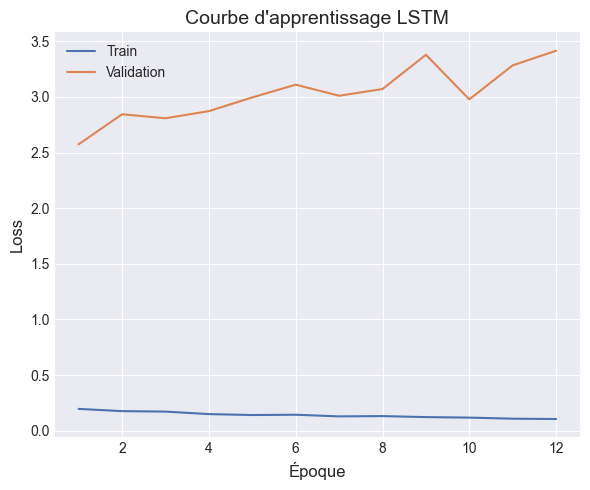

In [18]:
plt.figure(figsize=(6, 5))
plt.plot(range(1, len(train_history) + 1), train_history, label="Train")
plt.plot(range(1, len(val_history) + 1), val_history, label="Validation")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.title("Courbe d'apprentissage LSTM")
plt.legend()
plt.tight_layout()
plt.show()


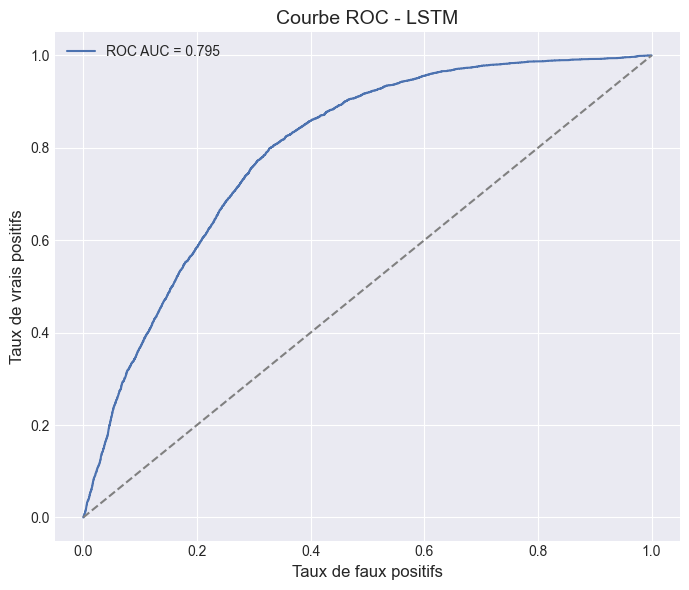

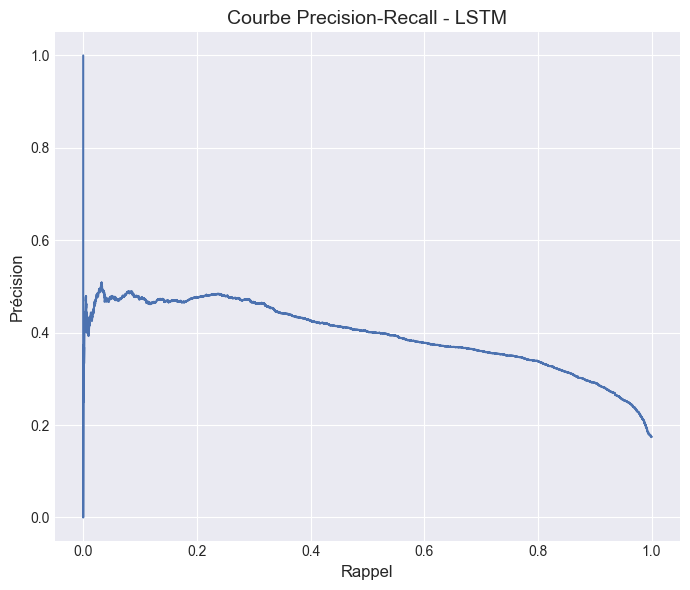

In [19]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(test_targets, test_probs)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - LSTM")
plt.legend()
plt.tight_layout()
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(test_targets, test_probs)
plt.figure(figsize=(7, 6))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe Precision-Recall - LSTM")
plt.tight_layout()
plt.show()


## Sauvegarde du modèle et du scaler

Nous sauvegardons les poids du LSTM, ainsi que le scaler utilisé pour la normalisation.


In [ ]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True, parents=True)

lstm_path = MODEL_DIR / "lstm_flood_risk.pt"
scaler_path = MODEL_DIR / "lstm_scaler.joblib"

torch.save(model.state_dict(), lstm_path)

import joblib
joblib.dump(scaler, scaler_path)

metadata = {
    "window_size": WINDOW_SIZE,
    "features": available_features,
    "train_size": len(train_df),
    "test_size": len(test_df),
    "threshold": threshold,
    "metrics": {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "average_precision": float(ap),
        "val_loss": float(val_loss),
    },
    "device": str(DEVICE),
}

metadata_path = MODEL_DIR / "lstm_flood_risk_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2))

lstm_path, scaler_path, metadata_path


## Pistes d'amélioration

- Ajuster la fenêtre (`WINDOW_SIZE`), le délai de prédiction (utiliser la classe `t+6h` voire `t+12h`).
- Rajouter des features (indicateurs hydrologiques, encoded time-of-day, sin/cos saisonnier).
- Utiliser un modèle bidirectionnel ou GRU, voire un Transformer temporel.
- Tester un apprentissage par ville (leave-one-location-out) pour évaluer la généralisation spatiale.
- Ajouter une calibration du seuil via les courbes précision-rappel pour correspondre aux besoins métiers.
